<a href="https://colab.research.google.com/github/PRManasa/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

(2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

None

churn
0    1969
1      31
Name: count, dtype: int64


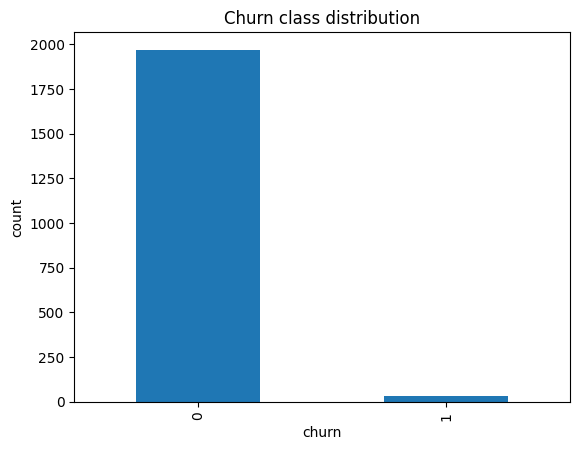

In [4]:
df = pd.read_csv("customer_churn_nn.csv")
print(df.shape)
display(df.head())
display(df.info())

class_counts = df["churn"].value_counts().sort_index()
print(class_counts)
class_counts.plot(kind="bar", title="Churn class distribution")
plt.xlabel("churn")
plt.ylabel("count")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = "churn"
id_col = "customer_id"

X = df.drop(columns=[target, id_col])
y = df[target]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

print("Training feature shape:", X_train_p.shape)
print("Testing feature shape:", X_test_p.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']
Training feature shape: (1600, 28)
Testing feature shape: (400, 28)
Training target shape: (1600,)
Testing target shape: (400,)


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
model = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train_p,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

train_loss, train_accuracy = model.evaluate(X_train_p, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test_p, y_test, verbose=0)
print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)
print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8789 - loss: 0.4049 - val_accuracy: 0.9937 - val_loss: 0.1792
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.1336 - val_accuracy: 0.9937 - val_loss: 0.0670
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.0936 - val_accuracy: 0.9937 - val_loss: 0.0476
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.0858 - val_accuracy: 0.9937 - val_loss: 0.0426
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0821 - val_accuracy: 0.9937 - val_loss: 0.0405
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.0792 - val_accuracy: 0.9937 - val_loss: 0.0393
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.0767 - val_accuracy: 0.9937 - val_loss: 0.0383
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0746 - val_accuracy: 0.9937 - val_loss

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Confusion Matrix:
[[394   0]
 [  6   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


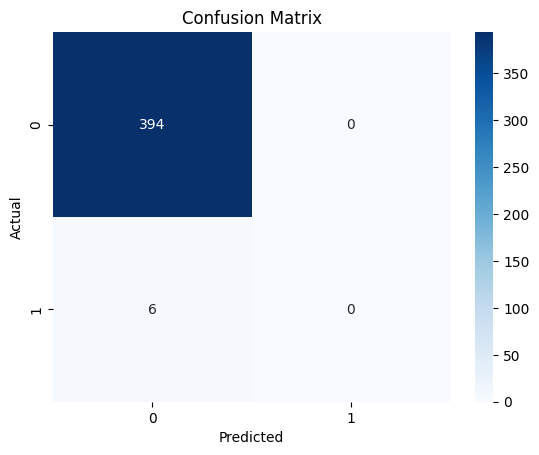

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_p)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
def build_model(hidden_units=32, second_layer_units=16, learning_rate=0.001, activation="relu"):
    model = keras.Sequential([
        layers.Input(shape=(X_train_p.shape[1],)),
        layers.Dense(hidden_units, activation=activation),
        layers.Dense(second_layer_units, activation=activation),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [10]:
experiments = [
    {
        "experiment": "Model 1",
        "hidden_units": 32,
        "second_layer_units": 16,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 20,
        "activation": "relu"
    },
    {
        "experiment": "Model 2",
        "hidden_units": 64,
        "second_layer_units": 32,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 20,
        "activation": "relu"
    },
    {
        "experiment": "Model 3",
        "hidden_units": 32,
        "second_layer_units": 16,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "epochs": 20,
        "activation": "tanh"
    }
]

results = []

for exp in experiments:
    model_exp = build_model(
        hidden_units=exp["hidden_units"],
        second_layer_units=exp["second_layer_units"],
        learning_rate=exp["learning_rate"],
        activation=exp["activation"]
    )

    history_exp = model_exp.fit(
        X_train_p,
        y_train,
        validation_split=0.2,
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
        verbose=0
    )

    test_loss, test_accuracy = model_exp.evaluate(X_test_p, y_test, verbose=0)

    results.append({
        "Experiment": exp["experiment"],
        "Hidden Units": exp["hidden_units"],
        "Second Layer Units": exp["second_layer_units"],
        "Learning Rate": exp["learning_rate"],
        "Batch Size": exp["batch_size"],
        "Epochs": exp["epochs"],
        "Activation": exp["activation"],
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)
results_df

,Experiment,Hidden Units,Second Layer Units,Learning Rate,Batch Size,Epochs,Activation,Test Loss,Test Accuracy
0,Model 1,32,16,0.0010,32,20,relu,0.060109,0.9875
1,Model 2,64,32,0.0010,32,20,relu,0.063123,0.9850
2,Model 3,32,16,0.0005,64,20,tanh,0.068750,0.9850
